In [2]:
# Step 1: Setup
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Set memory growth to avoid GPU issues (optional for Colab)
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


Image shape: (500, 500, 3)
Head Bounding Box: tf.Tensor([[0.154 0.178 0.53  0.566]], shape=(1, 4), dtype=float32)
Species (0=cat, 1=dog): tf.Tensor(0, shape=(), dtype=int64)


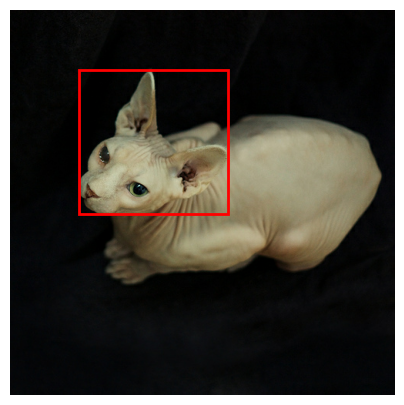

In [4]:
# Step 2 (Fixed): Load and Inspect the Dataset
dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=False)

# Sample a training image
sample = next(iter(dataset['train']))

image = sample['image']
bbox = tf.convert_to_tensor([sample['head_bbox']], dtype=tf.float32)  # Wrap in list to mimic 'objects'
label = sample['species']  # 0 = cat, 1 = dog

print("Image shape:", image.shape)
print("Head Bounding Box:", bbox)
print("Species (0=cat, 1=dog):", label)

# Visualization
def show_image_with_boxes(image, boxes):
    image = tf.cast(image, tf.uint8)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    for box in boxes:
        ymin, xmin, ymax, xmax = box
        h, w, _ = image.shape
        rect = plt.Rectangle((xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
                             fill=False, color='red', linewidth=2)
        plt.gca().add_patch(rect)
    plt.axis('off')
    plt.show()

show_image_with_boxes(image, bbox)

In [8]:
# Step 3: Preprocessing Function
def preprocess_sample(sample):
    image = tf.image.resize(sample['image'], (224, 224)) / 255.0
    bbox = tf.convert_to_tensor([sample['head_bbox']], dtype=tf.float32)  # Keep as list
    label = tf.cast(sample['species'], tf.int64)  # 0 = cat, 1 = dog
    return image, {'bbox': bbox, 'label': label}

# Apply to train/test splits
train_ds = dataset['train'].map(preprocess_sample).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = dataset['test'].map(preprocess_sample).batch(32).prefetch(tf.data.AUTOTUNE)

# Test one batch
for images, targets in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", targets['label'].shape)
    print("Batch bbox shape:", targets['bbox'].shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch bbox shape: (32, 1, 4)


In [11]:
from tensorflow.keras.applications import MobileNetV2

def build_model():
    # Load MobileNetV2 without top layers, frozen
    base_model = MobileNetV2(input_shape=(224, 224, 3),
                             include_top=False,
                             weights='imagenet')
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)

    # Bounding box head
    bbox_head = layers.Dense(128, activation='relu')(x)
    bbox_output = layers.Dense(4, activation='sigmoid', name='bbox')(bbox_head)

    # Classification head
    class_head = layers.Dense(128, activation='relu')(x)
    class_output = layers.Dense(2, activation='softmax', name='label')(class_head)

    model = tf.keras.Model(inputs=inputs, outputs={'bbox': bbox_output, 'label': class_output})
    return model

# Build it
model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mobilenetv2_1.00_224      │ (None, 7, 7, 1280)     │      2,257,984 │ input_image[0][0]      │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 1280)           │              0 │ mobilenetv2_1.00_224[… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │        163,968 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │        163,968 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bbox (Dense)              │ (None, 4)              │            516 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ label (Dense)             │ (None, 2)              │            258 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,586,694 (9.87 MB)

 Trainable params: 328,710 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss={
        'bbox': 'mean_squared_error',
        'label': 'sparse_categorical_crossentropy',
    },
    metrics={
        'bbox': 'mse',
        'label': 'accuracy',
    }
)

# Train it (let's do 5 epochs to keep it quick)
history = model.fit(train_ds, validation_data=test_ds, epochs=5)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - bbox_loss: 0.0378 - bbox_mse: 0.0378 - label_accuracy: 0.9244 - label_loss: 0.1631 - loss: 0.2009 - val_bbox_loss: 0.2164 - val_bbox_mse: 0.2164 - val_label_accuracy: 0.9899 - val_label_loss: 0.0316 - val_loss: 0.2480
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - bbox_loss: 0.0261 - bbox_mse: 0.0261 - label_accuracy: 0.9948 - label_loss: 0.0164 - loss: 0.0424 - val_bbox_loss: 0.2193 - val_bbox_mse: 0.2193 - val_label_accuracy: 0.9779 - val_label_loss: 0.0646 - val_loss: 0.2841
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 314s 3s/step - bbox_loss: 0.0238 - bbox_mse: 0.0238 - label_accuracy: 0.9964 - label_loss: 0.0115 - loss: 0.0353 - val_bbox_loss: 0.2240 - val_bbox_mse: 0.2240 - val_label_accuracy: 0.9866 - val_label_loss: 0.0449 - val_loss: 0.2691
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - bbox_loss: 0.0233 - bbox_mse: 0.0233 - label_accuracy: 0.9951 - label_loss: 0.0124 - loss: 0.0357 - val_bbox_loss: 0.2226 - val_bb

In [13]:
# Save the model
model.save("pet_detector_model.h5")